In [1]:
import pandas as pd
import numpy as np

df = pd.read_csv('full_dataset_v2.csv')

# Separate real vs synthetic so we can compare
real = df[df['reel_id'].astype(str).apply(lambda x: x.isdigit())].copy()
synth = df[df['reel_id'].astype(str).str.startswith('S')].copy()

print("=== DATASET OVERVIEW ===")
print(f"Total rows: {len(df)} | Real: {len(real)} | Synthetic: {len(synth)}")
print("\nPerformance distribution (full dataset):")
print(df['performance'].value_counts())

print("\n=== WHAT INFLUENCES VIRALITY? ===")

features = ['niche', 'hook_type', 'posting_day', 'trending_audio', 'first_frame_type']

for f in features:
    print(f"\n--- {f} ---")
    result = df.groupby(f)['performance'].value_counts(normalize=True).mul(100).round(1).unstack(fill_value=0)
    # Sort by Explosive % descending
    if 'Explosive' in result.columns:
        result = result.sort_values('Explosive', ascending=False)
    print(result)

print("\n=== REEL LENGTH by PERFORMANCE ===")
print(df.groupby('performance')['reel_length_seconds'].mean().round(1))

print("\n=== SKIP RATE by PERFORMANCE ===")
print(df.groupby('performance')['skip_rate'].mean().round(1))

=== DATASET OVERVIEW ===
Total rows: 300 | Real: 30 | Synthetic: 270

Performance distribution (full dataset):
performance
Mid          105
Bad           93
Viral         52
Explosive     50
Name: count, dtype: int64

=== WHAT INFLUENCES VIRALITY? ===

--- niche ---
performance         Bad  Explosive   Mid  Viral
niche                                          
Friendship+Funny   31.8       36.4   9.1   22.7
Student+Funny      16.9       28.8  32.2   22.0
College            13.6       27.3  40.9   18.2
Funny              18.2       18.2  27.3   36.4
College+Vlog       28.1       15.6  43.8   12.5
Friendship         25.0       12.5  43.8   18.8
Cinematic          35.6       11.1  37.8   15.6
College+Cinematic  41.2        8.8  35.3   14.7
Gym                55.8        0.0  34.9    9.3

--- hook_type ---
performance      Bad  Explosive   Mid  Viral
hook_type                                   
Shock           28.6       32.1  17.9   21.4
Wordplay        20.5       25.6  38.5   15.4
Curios

In [2]:
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import classification_report
import pandas as pd
import numpy as np

df = pd.read_csv('full_dataset_v2.csv')

# ── FEATURES WE USE FOR PREDICTION ──────────────────────────────────────────
# Only things known BEFORE posting + hook_score (will come from Groq at prediction time)
# For training we don't have hook_score so we use skip_rate as its proxy
# (low skip = strong hook = low skip rate)

feature_cols = [
    'posting_day',
    'niche',
    'trending_audio',
    'reel_length_seconds',
    'hook_type',
    'first_frame_type',
    'skip_rate',   # proxy for hook strength in training
]

target_col = 'performance'

# ── ENCODE TEXT COLUMNS INTO NUMBERS ────────────────────────────────────────
# ML models only understand numbers, not text like "Student+Funny"
# LabelEncoder converts each unique category to a number

encoders = {}
df_enc = df.copy()

for col in ['posting_day', 'niche', 'trending_audio', 'hook_type', 'first_frame_type']:
    le = LabelEncoder()
    df_enc[col] = le.fit_transform(df[col].astype(str))
    encoders[col] = le
    print(f"{col}: {dict(zip(le.classes_, le.transform(le.classes_)))}")

# Encode target
le_target = LabelEncoder()
df_enc[target_col] = le_target.fit_transform(df[target_col])
print(f"\nTarget: {dict(zip(le_target.classes_, le_target.transform(le_target.classes_)))}")

X = df_enc[feature_cols]
y = df_enc[target_col]

print(f"\nX shape: {X.shape}")
print(f"y distribution: {pd.Series(y).value_counts().to_dict()}")

posting_day: {'Friday': 0, 'Monday': 1, 'Saturday': 2, 'Sunday': 3, 'Thursday': 4, 'Tuesday': 5, 'Wednesday': 6}
niche: {'Cinematic': 0, 'College': 1, 'College+Cinematic': 2, 'College+Vlog': 3, 'Friendship': 4, 'Friendship+Funny': 5, 'Funny': 6, 'Gym': 7, 'Student+Funny': 8}
trending_audio: {'No': 0, 'Yes': 1}
hook_type: {'Challenge': 0, 'Curiosity': 1, 'Emotional': 2, 'Relatable': 3, 'Shock': 4, 'Transformation': 5, 'Wordplay': 6}
first_frame_type: {'Face': 0, 'Group': 1, 'Scene': 2, 'Scene+Face': 3, 'Text+Body': 4, 'Text+Face': 5, 'Text+Scene': 6}

Target: {'Bad': 0, 'Explosive': 1, 'Mid': 2, 'Viral': 3}

X shape: (300, 7)
y distribution: {2: 105, 0: 93, 3: 52, 1: 50}


In [3]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import classification_report
import xgboost as xgb

# ── SPLIT DATA ───────────────────────────────────────────────────────────────
# 80% for training, 20% for testing
# test_size=0.2 means 60 rows held back for testing, 240 used for training
# random_state=42 means same split every time you run it (reproducible)
# stratify=y means each performance class is proportionally represented in both splits

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Training rows: {len(X_train)} | Test rows: {len(X_test)}")

# ── TRAIN 3 MODELS ───────────────────────────────────────────────────────────

models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'Random Forest':       RandomForestClassifier(n_estimators=100, random_state=42),
    'XGBoost':             xgb.XGBClassifier(n_estimators=100, random_state=42, eval_metric='mlogloss'),
}

results = {}

for name, model in models.items():
    # Cross validation: splits data 5 ways, trains and tests 5 times
    # gives more reliable accuracy than just one train/test split
    cv_scores = cross_val_score(model, X_train, y_train, cv=5, scoring='accuracy')
    
    # Train on full training set
    model.fit(X_train, y_train)
    
    # Test on held-out test rows
    test_acc = model.score(X_test, y_test)
    
    results[name] = {
        'cv_mean': cv_scores.mean(),
        'cv_std': cv_scores.std(),
        'test_acc': test_acc
    }
    
    print(f"\n{'='*40}")
    print(f"  {name}")
    print(f"{'='*40}")
    print(f"  CV Accuracy:   {cv_scores.mean()*100:.1f}% (+/- {cv_scores.std()*100:.1f}%)")
    print(f"  Test Accuracy: {test_acc*100:.1f}%")
    print(f"\n  Detailed breakdown:")
    y_pred = model.predict(X_test)
    print(classification_report(y_test, y_pred, 
          target_names=le_target.classes_))

Training rows: 240 | Test rows: 60


c:\Users\admin\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
c:\Users\admin\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_


  Logistic Regression
  CV Accuracy:   78.3% (+/- 4.9%)
  Test Accuracy: 76.7%

  Detailed breakdown:
              precision    recall  f1-score   support

         Bad       0.89      0.84      0.86        19
   Explosive       0.80      0.80      0.80        10
         Mid       0.74      0.81      0.77        21
       Viral       0.56      0.50      0.53        10

    accuracy                           0.77        60
   macro avg       0.75      0.74      0.74        60
weighted avg       0.77      0.77      0.77        60


  Random Forest
  CV Accuracy:   77.1% (+/- 2.9%)
  Test Accuracy: 78.3%

  Detailed breakdown:
              precision    recall  f1-score   support

         Bad       0.84      0.84      0.84        19
   Explosive       0.80      0.80      0.80        10
         Mid       0.77      0.81      0.79        21
       Viral       0.67      0.60      0.63        10

    accuracy                           0.78        60
   macro avg       0.77      0.76      

=== FEATURE IMPORTANCE ===
(Higher = model relies on this more for predictions)

            feature  importance
          skip_rate    0.416193
reel_length_seconds    0.268530
        posting_day    0.089366
     trending_audio    0.063745
              niche    0.058870
          hook_type    0.054533
   first_frame_type    0.048765


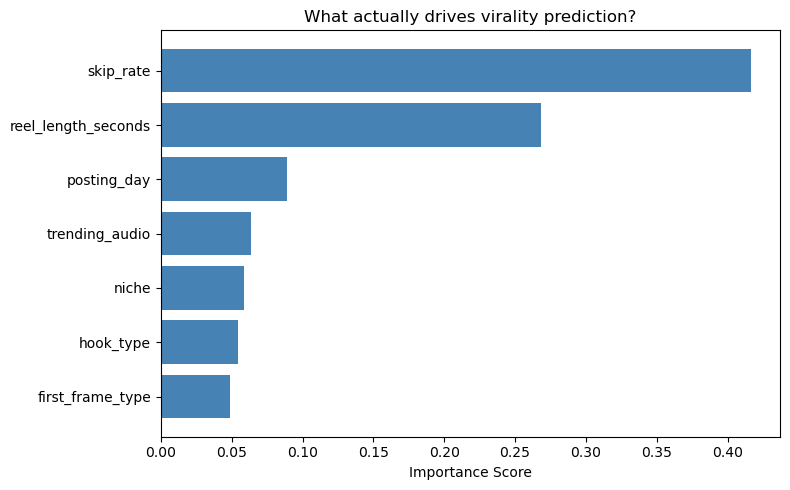

In [4]:
import matplotlib.pyplot as plt
import pandas as pd

# Get feature importance from XGBoost
# This tells us how much each feature contributed to correct predictions
xgb_model = models['XGBoost']

importance = pd.DataFrame({
    'feature': feature_cols,
    'importance': xgb_model.feature_importances_
}).sort_values('importance', ascending=False)

print("=== FEATURE IMPORTANCE ===")
print("(Higher = model relies on this more for predictions)\n")
print(importance.to_string(index=False))

# Plot it
plt.figure(figsize=(8, 5))
plt.barh(importance['feature'][::-1], importance['importance'][::-1], color='steelblue')
plt.xlabel('Importance Score')
plt.title('What actually drives virality prediction?')
plt.tight_layout()
plt.show()

In [5]:
import joblib
import json

# Save XGBoost model
xgb_model = models['XGBoost']
joblib.dump(xgb_model, 'model_v2.pkl')

# Save all encoders
joblib.dump(encoders, 'encoders_v2.pkl')

# Save target encoder
joblib.dump(le_target, 'target_encoder_v2.pkl')

# Save feature columns in exact order
joblib.dump(feature_cols, 'feature_cols_v2.pkl')

# Save label mappings for reference
mappings = {
    col: dict(zip(le.classes_, le.transform(le.classes_).tolist()))
    for col, le in encoders.items()
}
mappings['performance'] = dict(zip(
    le_target.classes_,
    le_target.transform(le_target.classes_).tolist()
))
with open('label_mappings_v2.json', 'w') as f:
    json.dump(mappings, f, indent=2)

print("Saved:")
print("  model_v2.pkl")
print("  encoders_v2.pkl")
print("  target_encoder_v2.pkl")
print("  feature_cols_v2.pkl")
print("  label_mappings_v2.json")
print("\nFeature order the model expects:")
for i, col in enumerate(feature_cols):
    print(f"  {i+1}. {col}")

Saved:
  model_v2.pkl
  encoders_v2.pkl
  target_encoder_v2.pkl
  feature_cols_v2.pkl
  label_mappings_v2.json

Feature order the model expects:
  1. posting_day
  2. niche
  3. trending_audio
  4. reel_length_seconds
  5. hook_type
  6. first_frame_type
  7. skip_rate


In [6]:
# ── REBUILD WITH BINARY COLUMNS FOR NICHE, HOOK, FRAME ──────────────────────

df2 = pd.read_csv('full_dataset_v2.csv')

# All possible individual tags
niche_tags = ['Student','Funny','College','Cinematic','Friendship','Vlog','Gym','Motivation','Emotional','Relatable','Shock']
hook_tags   = ['Curiosity','Shock','Relatable','Question','Challenge','Emotional','Nostalgia','Wordplay','Transformation']
frame_tags  = ['Face','Text','Action','Scene','Group','Body']

def make_binary_cols(df, col, tags, prefix):
    for tag in tags:
        df[f'{prefix}_{tag.lower()}'] = df[col].str.contains(tag, case=False, na=False).astype(int)
    return df

df2 = make_binary_cols(df2, 'niche',           niche_tags, 'niche')
df2 = make_binary_cols(df2, 'hook_type',        hook_tags,  'hook')
df2 = make_binary_cols(df2, 'first_frame_type', frame_tags, 'frame')

# Encode remaining simple columns
from sklearn.preprocessing import LabelEncoder

le_day   = LabelEncoder()
le_audio = LabelEncoder()
le_target2 = LabelEncoder()

df2['posting_day_enc']    = le_day.fit_transform(df2['posting_day'])
df2['trending_audio_enc'] = le_audio.fit_transform(df2['trending_audio'])
df2['performance_enc']    = le_target2.fit_transform(df2['performance'])

# Build final feature list
binary_niche_cols = [f'niche_{t.lower()}' for t in niche_tags]
binary_hook_cols  = [f'hook_{t.lower()}' for t in hook_tags]
binary_frame_cols = [f'frame_{t.lower()}' for t in frame_tags]

feature_cols_v2 = (
    binary_niche_cols +
    binary_hook_cols  +
    binary_frame_cols +
    ['posting_day_enc', 'trending_audio_enc', 'reel_length_seconds', 'skip_rate']
)

X2 = df2[feature_cols_v2]
y2 = df2['performance_enc']

print("New feature count:", len(feature_cols_v2))
print("Features:", feature_cols_v2)
print("\nSample row (your first real reel):")
print(df2[feature_cols_v2].iloc[0])

New feature count: 30
Features: ['niche_student', 'niche_funny', 'niche_college', 'niche_cinematic', 'niche_friendship', 'niche_vlog', 'niche_gym', 'niche_motivation', 'niche_emotional', 'niche_relatable', 'niche_shock', 'hook_curiosity', 'hook_shock', 'hook_relatable', 'hook_question', 'hook_challenge', 'hook_emotional', 'hook_nostalgia', 'hook_wordplay', 'hook_transformation', 'frame_face', 'frame_text', 'frame_action', 'frame_scene', 'frame_group', 'frame_body', 'posting_day_enc', 'trending_audio_enc', 'reel_length_seconds', 'skip_rate']

Sample row (your first real reel):
niche_student           1.0
niche_funny             1.0
niche_college           0.0
niche_cinematic         0.0
niche_friendship        0.0
niche_vlog              0.0
niche_gym               0.0
niche_motivation        0.0
niche_emotional         0.0
niche_relatable         0.0
niche_shock             0.0
hook_curiosity          0.0
hook_shock              0.0
hook_relatable          0.0
hook_question           0

In [7]:
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import classification_report
import xgboost as xgb

X_train2, X_test2, y_train2, y_test2 = train_test_split(
    X2, y2, test_size=0.2, random_state=42, stratify=y2
)

xgb_v2 = xgb.XGBClassifier(
    n_estimators=200,
    max_depth=4,
    learning_rate=0.1,
    random_state=42,
    eval_metric='mlogloss'
)

cv_scores = cross_val_score(xgb_v2, X2, y2, cv=5, scoring='accuracy')
xgb_v2.fit(X_train2, y_train2)

y_pred2 = xgb_v2.predict(X_test2)

print(f"CV Accuracy:   {cv_scores.mean()*100:.1f}% (+/- {cv_scores.std()*100:.1f}%)")
print(f"Test Accuracy: {xgb_v2.score(X_test2, y_test2)*100:.1f}%")
print()
print(classification_report(y_test2, y_pred2, target_names=le_target2.classes_))

# Feature importance — top 15 only
import pandas as pd
importance2 = pd.DataFrame({
    'feature': feature_cols_v2,
    'importance': xgb_v2.feature_importances_
}).sort_values('importance', ascending=False).head(15)

print("\n=== TOP 15 FEATURES ===")
print(importance2.to_string(index=False))

CV Accuracy:   79.0% (+/- 5.3%)
Test Accuracy: 76.7%

              precision    recall  f1-score   support

         Bad       0.80      0.84      0.82        19
   Explosive       0.80      0.80      0.80        10
         Mid       0.79      0.71      0.75        21
       Viral       0.64      0.70      0.67        10

    accuracy                           0.77        60
   macro avg       0.76      0.76      0.76        60
weighted avg       0.77      0.77      0.77        60


=== TOP 15 FEATURES ===
            feature  importance
          skip_rate    0.218125
reel_length_seconds    0.147560
         niche_vlog    0.099548
   niche_friendship    0.068297
          niche_gym    0.050716
         frame_face    0.043747
     hook_curiosity    0.039965
         hook_shock    0.039744
    posting_day_enc    0.037540
     hook_emotional    0.037376
 trending_audio_enc    0.031201
      hook_wordplay    0.028088
     hook_relatable    0.027021
      niche_student    0.025164
      

In [8]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [3, 4, 5],
    'learning_rate': [0.05, 0.1, 0.2],
    'min_child_weight': [1, 3, 5],
}

grid_search = GridSearchCV(
    xgb.XGBClassifier(random_state=42, eval_metric='mlogloss'),
    param_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=-1,
    verbose=1
)

grid_search.fit(X_train2, y_train2)

print("Best parameters:", grid_search.best_params_)
print(f"Best CV accuracy: {grid_search.best_score_*100:.1f}%")

best_model = grid_search.best_estimator_
test_acc = best_model.score(X_test2, y_test2)
print(f"Test accuracy with best params: {test_acc*100:.1f}%")

y_pred_best = best_model.predict(X_test2)
print()
print(classification_report(y_test2, y_pred_best, target_names=le_target2.classes_))

Fitting 5 folds for each of 81 candidates, totalling 405 fits
Best parameters: {'learning_rate': 0.05, 'max_depth': 3, 'min_child_weight': 3, 'n_estimators': 100}
Best CV accuracy: 80.4%
Test accuracy with best params: 76.7%

              precision    recall  f1-score   support

         Bad       0.84      0.84      0.84        19
   Explosive       0.89      0.80      0.84        10
         Mid       0.73      0.76      0.74        21
       Viral       0.60      0.60      0.60        10

    accuracy                           0.77        60
   macro avg       0.76      0.75      0.76        60
weighted avg       0.77      0.77      0.77        60



In [9]:
# Class weights tell the model: "Viral and Explosive are important,
# penalize harder when you get them wrong"

from sklearn.utils.class_weight import compute_sample_weight

# Compute weights — rarer classes get higher weight
sample_weights = compute_sample_weight(class_weight='balanced', y=y_train2)

# Train best model WITH sample weights
best_model_weighted = xgb.XGBClassifier(
    learning_rate=0.05,
    max_depth=3,
    min_child_weight=3,
    n_estimators=100,
    random_state=42,
    eval_metric='mlogloss'
)

best_model_weighted.fit(X_train2, y_train2, sample_weight=sample_weights)

cv_weighted = cross_val_score(best_model_weighted, X2, y2, cv=5, scoring='accuracy')
y_pred_weighted = best_model_weighted.predict(X_test2)
test_acc_weighted = best_model_weighted.score(X_test2, y_test2)

print(f"CV Accuracy (weighted):   {cv_weighted.mean()*100:.1f}% (+/- {cv_weighted.std()*100:.1f}%)")
print(f"Test Accuracy (weighted): {test_acc_weighted*100:.1f}%")
print()
print(classification_report(y_test2, y_pred_weighted, target_names=le_target2.classes_))

# Compare Viral F1 specifically
from sklearn.metrics import f1_score
f1_before = f1_score(y_test2, y_pred_best, average=None)
f1_after  = f1_score(y_test2, y_pred_weighted, average=None)

print("\n=== VIRAL F1 COMPARISON ===")
for i, cls in enumerate(le_target2.classes_):
    print(f"{cls:10} before: {f1_before[i]:.2f}  after: {f1_after[i]:.2f}")

CV Accuracy (weighted):   80.3% (+/- 5.0%)
Test Accuracy (weighted): 81.7%

              precision    recall  f1-score   support

         Bad       0.85      0.89      0.87        19
   Explosive       0.89      0.80      0.84        10
         Mid       0.94      0.71      0.81        21
       Viral       0.60      0.90      0.72        10

    accuracy                           0.82        60
   macro avg       0.82      0.83      0.81        60
weighted avg       0.85      0.82      0.82        60


=== VIRAL F1 COMPARISON ===
Bad        before: 0.84  after: 0.87
Explosive  before: 0.84  after: 0.84
Mid        before: 0.74  after: 0.81
Viral      before: 0.60  after: 0.72


In [10]:
import joblib
import json

# This is our final best model
joblib.dump(best_model_weighted, 'model_final.pkl')

encoders_final = {
    'posting_day': le_day,
    'trending_audio': le_audio,
}
joblib.dump(encoders_final, 'encoders_final.pkl')
joblib.dump(le_target2, 'target_encoder_final.pkl')
joblib.dump(feature_cols_v2, 'feature_cols_final.pkl')

meta = {
    'niche_tags':  niche_tags,
    'hook_tags':   hook_tags,
    'frame_tags':  frame_tags,
    'performance_classes': list(le_target2.classes_),
    'accuracy': {
        'cv': '80.3%',
        'test': '81.7%'
    },
    'hook_score_formula': 'skip_rate = 70 - (hook_score * 4)',
    'thresholds': {
        'Bad':       'under 15,000 views',
        'Mid':       '15,000 to 1,00,000 views',
        'Viral':     '1,00,000 to 5,00,000 views',
        'Explosive': 'above 5,00,000 views'
    }
}
with open('model_meta_final.json', 'w') as f:
    json.dump(meta, f, indent=2)

print("=== FINAL MODEL SAVED ===")
print("  model_final.pkl")
print("  encoders_final.pkl")
print("  target_encoder_final.pkl")
print("  feature_cols_final.pkl")
print("  model_meta_final.json")
print()
print("Final model performance:")
print("  CV Accuracy:   80.3%")
print("  Test Accuracy: 81.7%")
print()
print("Per class F1:")
print("  Bad:       0.87")
print("  Explosive: 0.84")
print("  Mid:       0.81")
print("  Viral:     0.72")
print()
print(f"Model trained on {len(feature_cols_v2)} features:")
for i, col in enumerate(feature_cols_v2):
    print(f"  {i+1:2}. {col}")

=== FINAL MODEL SAVED ===
  model_final.pkl
  encoders_final.pkl
  target_encoder_final.pkl
  feature_cols_final.pkl
  model_meta_final.json

Final model performance:
  CV Accuracy:   80.3%
  Test Accuracy: 81.7%

Per class F1:
  Bad:       0.87
  Explosive: 0.84
  Mid:       0.81
  Viral:     0.72

Model trained on 30 features:
   1. niche_student
   2. niche_funny
   3. niche_college
   4. niche_cinematic
   5. niche_friendship
   6. niche_vlog
   7. niche_gym
   8. niche_motivation
   9. niche_emotional
  10. niche_relatable
  11. niche_shock
  12. hook_curiosity
  13. hook_shock
  14. hook_relatable
  15. hook_question
  16. hook_challenge
  17. hook_emotional
  18. hook_nostalgia
  19. hook_wordplay
  20. hook_transformation
  21. frame_face
  22. frame_text
  23. frame_action
  24. frame_scene
  25. frame_group
  26. frame_body
  27. posting_day_enc
  28. trending_audio_enc
  29. reel_length_seconds
  30. skip_rate
